In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from scFM_density_estimation.models import *

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 4096
Batch size: 256


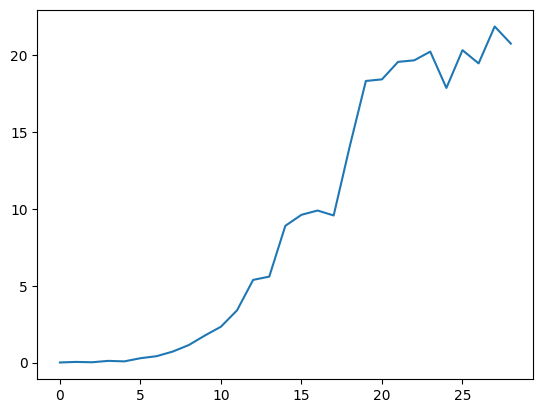

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 4096
Batch size: 1024


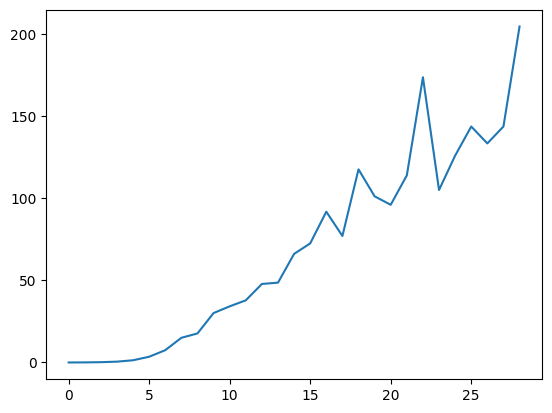

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 4096
Batch size: 4096


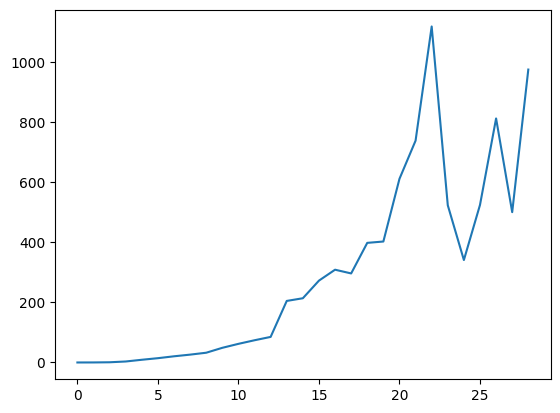

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 20000
Batch size: 256


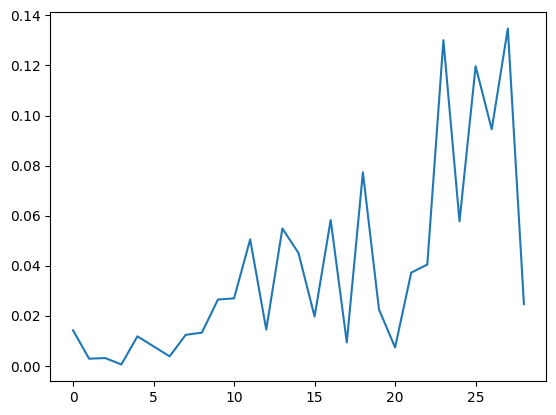

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 20000
Batch size: 1024


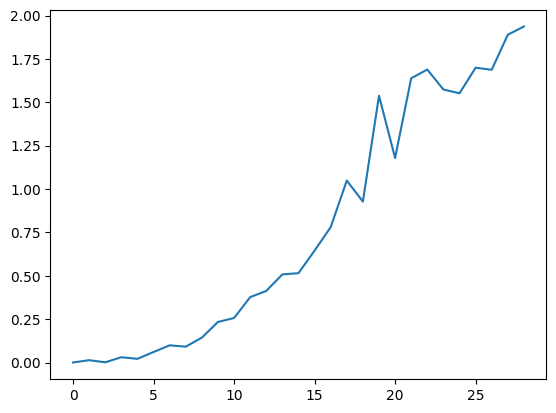

  0%|          | 0/29 [00:00<?, ?it/s]

Number of points: 20000
Batch size: 4096


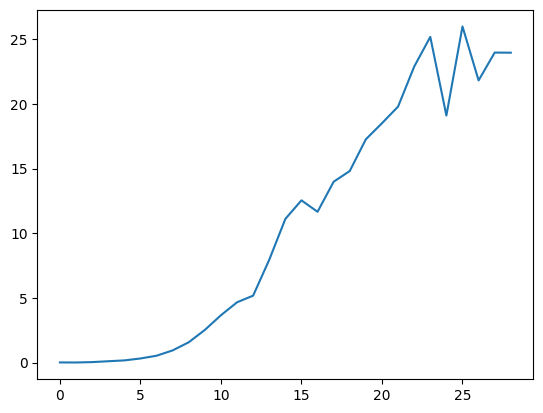

In [71]:
batch_sizes = [256, 1024, 4096]
Ns = [4096, 20000]

for N in Ns:
    for batch_size in batch_sizes:
        results = []
        for n in tqdm(range(2, 31)):
            X = np.random.normal(loc=5, scale=1, size=(N, n))
            y = np.random.randint(low=0, high=2, size=(N, 1))

            alpha = 0.999
            ema_loss = None
            model = ConditionalFlowMatching(input_dim=n, hidden_dims=[1024, 1024, 1024, 1024], cond_dim=1,
                                            use_encoder=False, use_ot_sampler=False).to("cuda")
            optimizer = model.configure_optimizers()
            
            mask = (y == 1).reshape(-1)
            X = torch.tensor(X).to("cuda").float()
            C = torch.tensor(y).to("cuda").float()
            
            for k in range(20000):
                optimizer.zero_grad()
        
                indices = np.random.choice(range(X.shape[0]), size=batch_size, replace=False)
                loss = model.shared_step(X[indices], C[indices])
                
                loss.backward()
                optimizer.step()
        
                # if ema_loss is None:
                #     ema_loss = loss.item()
                # else:
                #     ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 
            
                # if (k + 1) % 1000 == 0:
                #     print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
            
            group0 = model.estimate_log_density(X[mask], torch.zeros(size=(np.sum(mask), 1)).to("cuda").float())
            group1 = model.estimate_log_density(X[mask], torch.ones(size=(np.sum(mask), 1)).to("cuda").float())
            results.append(abs(np.median(group0 - group1)))

        print("Number of points:", N)
        print("Batch size:", batch_size)
        plt.plot(results)
        plt.show()
        print()